In [ ]:
import matplotlib
matplotlib.rc('font',**{'family':'serif','serif':['Latin Modern Roman']})
matplotlib.rc('text', usetex=False)
axislabelfontsize='large'
matplotlib.rcParams['figure.figsize'] = (5, 3)
import math
from tqdm import tqdm
import time
import os
import gdown


import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import shuffle
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Introduction to Beyond the Standard Model (BSM) Physics Analyses

When physicists formulate a new theory in particle physics—often referred to as a **model**—they must specify two fundamental components:

1. **The Particle Content:** What particles exist within the theory?
2. **The Interactions:** How do these particles interact with one another?

---

## 1. The Standard Model and Beyond

Our current best framework for understanding the subatomic world is the **Standard Model (SM)** of particle physics. The Standard Model contains a wide variety of known fundamental particles, ranging from matter particles like **electrons** and **quarks**, to force-carrying particles like **photons** and **gluons**, each possessing unique masses, charges, and quantum properties.

However, we know the Standard Model cannot explain everything in the Universe. To search for "New Physics" (often called **Beyond the Standard Model** or **BSM** physics), theoretical physicists propose new models. This typically involves:
* Postulating a hypothetical **new particle** to add to our theory.
* Specifying how this new particle couples to and interacts with known Standard Model particles.

---

## 2. Introducing a New Candidate: The Radion

In this tutorial, we will focus on a BSM model that introduces a hypothetical heavy scalar particle called the **Radion**.

The Radion interacts with all known Standard Model particles. Crucially, however, it does **not** interact with every particle with equal strength—it couples much more strongly to certain Standard Model particles than to others!



# Radion Production & Decay Channels

Before we look at our experimental data, let us build some physical intuition about how a heavy hypothetical particle like a **Radion** is produced at the Large Hadron Collider (LHC) and how we choose the best decay channel to search for it.

---

## 1. How is the Radion Produced?

At the LHC, beams of protons are accelerated to near the speed of light and brought into collision. Protons are not point-like particles—at very high energies, they consist of a dense sea of inner particles called **quarks** and **gluons**.

Because gluons carry the strong nuclear force and are abundantly present in high-energy proton collisions, the main way to create a heavy Radion ($\phi$) is through **gluon–gluon fusion**:

$$g + g \to \text{Radion}$$

Two energetic gluons interact to form the new heavy particle.

---

## 2. Radion Decays: What is Particle $A$?

Once produced, the Radion is unstable and decays almost instantly into a pair of Standard Model particles ($A + A$):

$$g + g \to \text{Radion} \to A + A$$

Depending on the mass of the Radion, it can decay into several different candidate pairs, such as vector bosons, Higgs bosons, or heavy quarks.

To describe how often a particle decays into a specific channel, physicists use a quantity called the **Branching Ratio ($\text{BR}$)**:

$$\text{Branching Ratio } (\text{BR}) = \frac{\text{Number of decays into a specific channel}}{\text{Total number of all decays}}$$

A higher branching ratio means that a specific decay happens more frequently, giving us more events to search for in our detector!

---

## 3. Student Task: Identify the Best Final State

Look carefully at the **Branching Ratio vs Radion Mass** plot shown below.

Imagine you are designing an experiment to discover a heavy Radion (with a mass **above** $300\text{ GeV}$). You want to select the decay channel $A + A$ that gives you the highest probability of producing signal events.

### Questions to Consider:
1. Which particle curve dominates (has the highest Branching Ratio) in the heavy mass region?
2. Why is choosing a channel with a high Branching Ratio advantageous when searching for rare New Physics events?

> **Question:**  
> Based on the plot below, which Standard Model particle should **$A$** be to give us the best chance of detection?
> *(Write down your choice and discuss it with your peers before moving on!)*

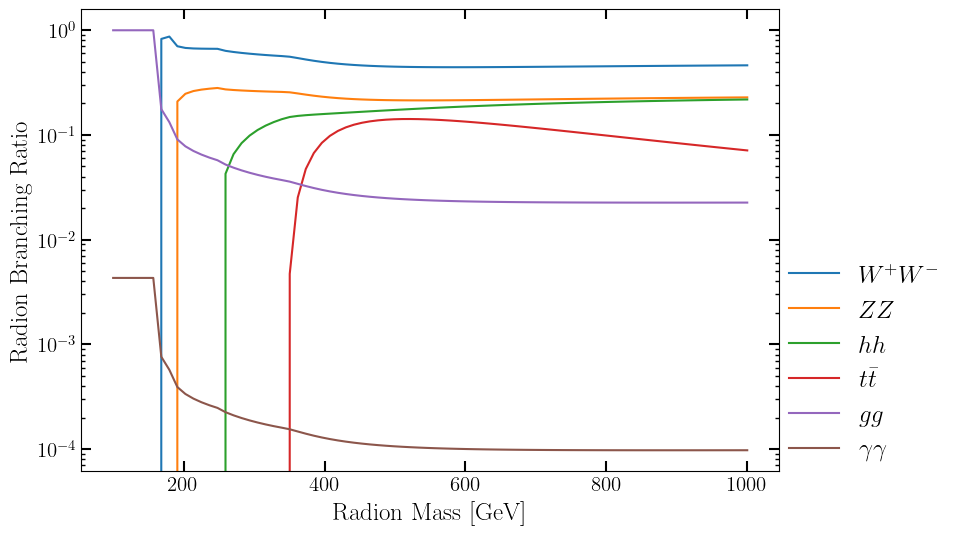

### Secondary Decays: Reaching the Final State

Many of the intermediate particles produced in Radion decays are unstable and decay almost instantaneously into the lighter particles our detector actually measures (such as jets, leptons, or photons). Their primary decay probabilities (branching ratios) are:

* **$W$ Boson:** Decays into 2 jets ($W \to jj$) ~70% of the time, and into leptons ~30% of the time.
* **$Z$ Boson:** Decays into 2 jets ($Z \to jj$) ~70% of the time, and into leptons ~30% of the time.
* **Higgs Boson ($H$):** Decays into bottom-quark jets ($H \to b\bar{b}$) ~60% of the time (with smaller fractions decaying to photons or leptons).

> **Question:**  
> Combining these secondary branching ratios with your chosen Radion decay channel from earlier, what is the best full process and final state to search for in our detector?  
> *(Hint: Try sketching a Feynman diagram from the initial $g + g$ collision all the way to the final detected particles! If you are not familiar with feynmann diagrams, look at the image below. It is a diagram, shaped like a tree, showing the steps between the initial state, which is g here, to the final states, which are Bs. What are A and B here?)*

<div style="width: 200px;">

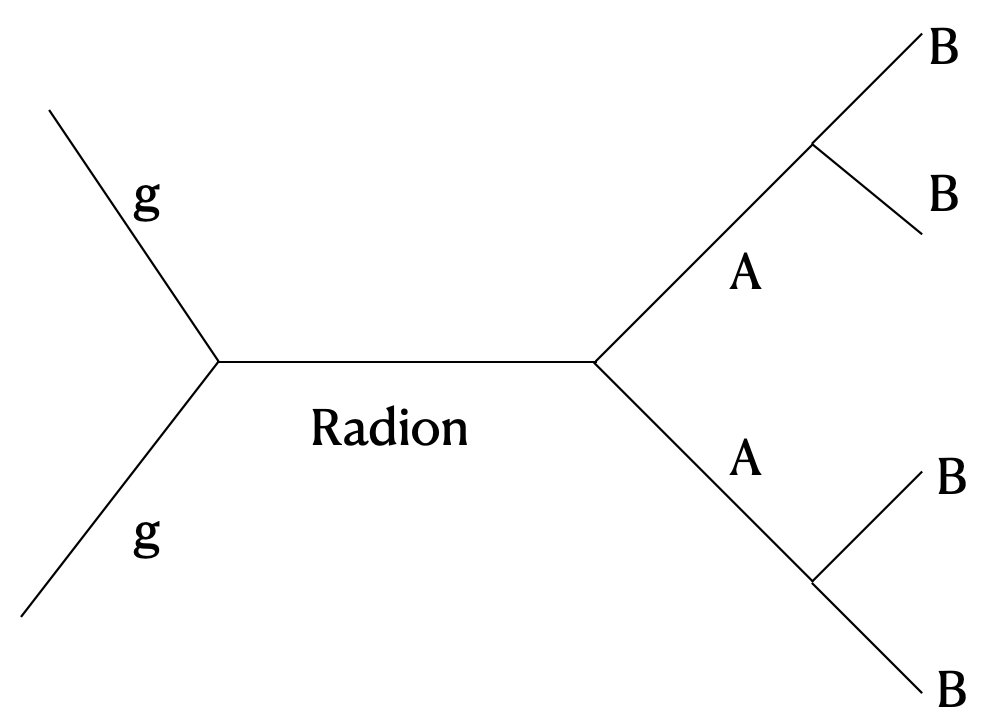

</div>


### CODE BEGINS

In this exercise, we are looking for a new hypothetical heavy particle called a **Radion** of mass $600$ GeV. All you need to keep in mind is this simple sequence of events:

1. A collision creates a **Radion**.
2. The Radion breaks apart into two **$W$ bosons**.
3. Each $W$ boson breaks apart into two **jets** (sprays of energetic particles detected in our experiment).

So, in total, our detector sees a **4-jet final state** for the **signal**:
* **2 jets** pair up to make the first $W$ boson ($W_1$).
* **2 jets** pair up to make the second $W$ boson ($W_2$).
* All **4 jets** together form the full **Radion**.



---

## 2. Variables Provided in Your Dataset

We have provided two datasets stored in Pandas DataFrames:
1. **Signal:** Each event containing 4 jets, which come from our hypothetical Radion particle.
2. **Background:** Standard Model events, also having 4 jets per event. The **background does not** have a simple structure in general i.e. no pairs of jets forming a W or pairs of W forming a radion.

From here on, we will refer to the pairs of jets as Ws for both signal and background. Remember, for the background this is a FAKE W!

The 4 jets in each event (from both the signal and background data) have already been paired up based on the spatial distance between them ($\Delta R$). The pairs are named W_1 and W_2. The two jets from the first pair are labelled W1_j1 and W1_j2, while the two from the second pair are labelled W2_j1 and W2_j2. The naming will be clear soon!


For each collision event, you have access to the following columns:

### Jet Kinematics & 4-Momenta
For each of the 4 jets (`W1_j1`, `W1_j2`, `W2_j1`, `W2_j2`), you are given:
* `pt`: Transverse momentum (momentum perpendicular to the beam line) i.e. $\sqrt{p_x^2+p_y^2}$.
* `eta`: Pseudorapidity $\eta$ (an angle-like coordinate measuring direction).
* `phi`: Azimuthal angle $\phi$.
* `E`: Energy of the jet.
* `px`, `py`, `pz`: The three components of spatial momentum.

* For example W1_j1_px is the x component of the momentum of W1_j1.

### Pre-Calculated Angle
* `cos_theta_WW`: The cosine of the opening angle $\cos\theta_{WW}$ between the two candidate $W$ bosons in the laboratory frame.




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

# Ensure your Events class is imported before running
# e.g., from py_lhco import Events


# 1. HELPER FUNCTIONS FOR KINEMATICS & PAIRING


def delta_r(eta1, phi1, eta2, phi2):
    """Calculates Delta R between two physics objects."""
    dphi = np.abs(phi1 - phi2)
    dphi = np.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    deta = eta1 - eta2
    return np.sqrt(deta**2 + dphi**2)

def to_4momentum(pt, eta, phi, m):
    """Converts (pt, eta, phi, m) into 4-vector (E, px, py, pz)."""
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E  = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    return np.array([E, px, py, pz])

def process_event_jets(ev):
    """
    Processes a single event: checks for >= 4 jets (no pt or eta cuts applied),
    sorts by PT, takes the top 4, pairs them into 2 W candidates based on min Delta R,
    and returns a formatted dictionary row.
    """
    if "jet" not in ev or len(ev["jet"]) < 4:
        return None

    # Sort all jets by PT descending without applying any cuts
    jets_final = sorted(ev["jet"], key=lambda x: x.get("PT", x.get("pt")), reverse=True)[:4]

    # Extract coordinates (handles uppercase/lowercase key variations)
    j_coords = []
    for j in jets_final:
        pt = j.get("PT", j.get("pt"))
        eta = j.get("eta", j.get("Eta"))
        phi = j.get("phi", j.get("Phi"))
        m = j.get("m", j.get("mass", 0.0))
        j_coords.append([pt, eta, phi, m])

    # Convert to 4-momenta
    p4 = [to_4momentum(*j) for j in j_coords]

    # Determine pairing by minimising total Delta R within pairs
    # Combo 0: (0,1) & (2,3) | Combo 1: (0,2) & (1,3) | Combo 2: (0,3) & (1,2)
    dR_0 = delta_r(j_coords[0][1], j_coords[0][2], j_coords[1][1], j_coords[1][2]) + \
           delta_r(j_coords[2][1], j_coords[2][2], j_coords[3][1], j_coords[3][2])

    dR_1 = delta_r(j_coords[0][1], j_coords[0][2], j_coords[2][1], j_coords[2][2]) + \
           delta_r(j_coords[1][1], j_coords[1][2], j_coords[3][1], j_coords[3][2])

    dR_2 = delta_r(j_coords[0][1], j_coords[0][2], j_coords[3][1], j_coords[3][2]) + \
           delta_r(j_coords[1][1], j_coords[1][2], j_coords[2][1], j_coords[2][2])

    best_combo = np.argmin([dR_0, dR_1, dR_2])

    if best_combo == 0:
        w1_idx, w2_idx = (0, 1), (2, 3)
    elif best_combo == 1:
        w1_idx, w2_idx = (0, 2), (1, 3)
    else:
        w1_idx, w2_idx = (0, 3), (1, 2)

    # Assign jets to W1 and W2
    j_w1_1, j_w1_2 = j_coords[w1_idx[0]], j_coords[w1_idx[1]]
    j_w2_1, j_w2_2 = j_coords[w2_idx[0]], j_coords[w2_idx[1]]

    p4_w1_1, p4_w1_2 = p4[w1_idx[0]], p4[w1_idx[1]]
    p4_w2_1, p4_w2_2 = p4[w2_idx[0]], p4[w2_idx[1]]

    # Compute 3-momenta and opening angle cos_theta_WW
    p3_w1 = (p4_w1_1 + p4_w1_2)[1:]
    p3_w2 = (p4_w2_1 + p4_w2_2)[1:]

    norm1 = np.linalg.norm(p3_w1)
    norm2 = np.linalg.norm(p3_w2)
    cos_theta_ww = np.dot(p3_w1, p3_w2) / (norm1 * norm2) if (norm1 * norm2) > 0 else 0.0

    return {
        # W1 - Jet 1
        'W1_j1_pt': j_w1_1[0], 'W1_j1_eta': j_w1_1[1], 'W1_j1_phi': j_w1_1[2],
        'W1_j1_E': p4_w1_1[0], 'W1_j1_px': p4_w1_1[1], 'W1_j1_py': p4_w1_1[2], 'W1_j1_pz': p4_w1_1[3],

        # W1 - Jet 2
        'W1_j2_pt': j_w1_2[0], 'W1_j2_eta': j_w1_2[1], 'W1_j2_phi': j_w1_2[2],
        'W1_j2_E': p4_w1_2[0], 'W1_j2_px': p4_w1_2[1], 'W1_j2_py': p4_w1_2[2], 'W1_j2_pz': p4_w1_2[3],

        # W2 - Jet 1
        'W2_j1_pt': j_w2_1[0], 'W2_j1_eta': j_w2_1[1], 'W2_j1_phi': j_w2_1[2],
        'W2_j1_E': p4_w2_1[0], 'W2_j1_px': p4_w2_1[1], 'W2_j1_py': p4_w2_1[2], 'W2_j1_pz': p4_w2_1[3],

        # W2 - Jet 2
        'W2_j2_pt': j_w2_2[0], 'W2_j2_eta': j_w2_2[1], 'W2_j2_phi': j_w2_2[2],
        'W2_j2_E': p4_w2_2[0], 'W2_j2_px': p4_w2_2[1], 'W2_j2_py': p4_w2_2[2], 'W2_j2_pz': p4_w2_2[3],

        # Angular correlation
        'cos_theta_WW': cos_theta_ww
    }



Run the code below to load the csv files containing the signal and background data

In [ ]:


#LOAD FROM CSV FILES & PRINT FRACTION

# Define your file dictionary mapping desired filenames to Google Drive File IDs
file_ids = {
    "signal_events.csv": "1Sxsg85_it6BsPZLCZclWvV3wh_V9-OZe",
    "background_events_combined.csv": "1eZVF0mrdJMx1sMdUUmcrSfvtXncxvPD0",
}

#Download each file using gdown if it doesn't already exist locally
for filename, file_id in file_ids.items():
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, filename, quiet=False)
    else:
        print(f"{filename} already exists. Skipping download.")

sig_csv_path = 'signal_events.csv'
bkg_csv_path = 'background_events_combined.csv'


# Extract into Pandas DataFrames
df_signal = pd.read_csv(sig_csv_path)
df_background = pd.read_csv(bkg_csv_path)

# Extract into NumPy 2D Arrays (if needed)
array_signal = df_signal.to_numpy()
array_background = df_background.to_numpy()

# Total generated events denominator
TOTAL_GENERATED_EVENTS_SIGNAL = 50000
TOTAL_GENERATED_EVENTS_BACKGROUND = 400000

# Calculate fractions
sig_fraction = len(df_signal) / TOTAL_GENERATED_EVENTS_SIGNAL
bkg_fraction = len(df_background) / TOTAL_GENERATED_EVENTS_BACKGROUND


print("\nPreview of Loaded Signal DataFrame:")
print(df_signal.head())

print(f"\nLoaded Signal NumPy array shape: {array_signal.shape}")
print(f"Loaded Background NumPy array shape: {array_background.shape}")



In [ ]:
# Run this to see the names of all the available parameters
df_signal.axes

> **TASK:**  
> The signal and background have some raw cross section. However, this is not the correct number to use. Only a certain fraction of signal and background events have 4 jets as the simulation data is not perfect. Using that fraction, calculate the correct cross section for the signal and background given that:
- raw signal cross section = 251 fb
- raw background cross section = 2918772862 fb

Run this cell to see the percentage of events with 4 jets.

In [ ]:
print("\n" + "="*50)
print("EVENT SELECTION FRACTIONS")
print("="*50)
print(f"Signal Fraction:      ({sig_fraction * 100:.2f}%)")
print(f"Background Fraction:  ({bkg_fraction * 100:.2f}%)")

Calculate the cross section from the fraction and store is below

In [ ]:
#SIGMA_SIGNAL_INIT     =
#SIGMA_BACKGROUND_INIT =

It is time to calculate some physics inspired variables
- The jets in the **signal** process are coming from the decay of W. Therefore, the sum of the energy/momenta of the jet pair should be the energy/momentum of the parent W. Therefore, if we calculate the mass of 2 jets combined using the formula $m_{~2 jets}=\sqrt{E^2-p_x^2-p_y^2-p_z^2}$, it should be the mass of the W, which is **80 GeV**. Since there are 2 pairs of jets, the mass of each pair should peak around 80 GeV for the signal. For the background, the W is a fake, so we **do not** expect the mass of each pair to be close to 80 GeV.

- That is why we named the pair of jets W1 and W2!
- Similarly, for the signal, if we add the momenta and energy of all the four jets and calculate the mass, call it m_4j, it should give us the mass of the radion. For the background, m_4j should not be close to the radion mass!



>**TASK:**  Calculate m_W1, m_W2 for both the Ws, and m_4j for both df_background and df_signal. Add your calculated columns to the DataFrames:

In [ ]:
#df_background['m_W1']=
#df_background['m_W2']=
#df_background['m_4j']=

#df_signal['m_W1']=
#df_signal['m_W2']=
#df_signal['m_4j']=

> **TASK:**  
> Calculate cos_theta_WW i.e. the cosine of the angle between the Ws (or fake Ws, for the background) from scratch using jet 3-momentum vectors (px, py, pz). Use the formula
$$\vec{A}\cdot \vec{B} = |\vec{A}||\vec{B}|cos \theta$$

> Compare your calculated array with the pre-computed column 'cos_theta_WW'
> Print the maximum difference between the two arrays to verify accuracy.



In [ ]:
# cos_theta_calculated = ...

# MANUAL CUTS




## Statistical Significance & Manual Cuts

Now that you have reconstructed the key physical quantities, let us look at how physicists decide whether a new signal has actually been discovered.

---

## 1. What is Statistical Significance?

In particle physics, searching for a new particle is like listening for a soft tune in a noisy environment:

* **Signal ($S$):** The number of New Physics events expected in our detector (e.g., Radion decays).
* **Background ($B$):** Standard Model events that mimic the signal signature.

Because quantum mechanical processes are inherently random, the background count fluctuates naturally from run to run. The statistical uncertainty on our total count is approximately given by $\sqrt{S + B}$.

To measure how confident we are that a bump in our data is a genuine discovery rather than a random background fluctuation, we define **Statistical Significance**:

$$\text{Significance} = \frac{S}{\sqrt{S + B}}$$

> **How to Interpret Significance:**
> * **Significance $< 2$:** The signal is obscured by background noise—we cannot draw firm conclusions.
> * **Significance $\ge 3$ ($3\sigma$):** Claimed as **"evidence"** for a new physical process.
> * **Significance $\ge 5$ ($5\sigma$):** The gold standard in particle physics required to claim an official **"discovery"**!

---

## 2. Instructions: Optimising Significance via Manual Cuts

Before applying machine learning algorithms like XGBoost, we will practice a traditional **cut-based analysis**

**TASK:** Try experimenting with different cut combinations! Please go to block 3 in the code below for specifying the cuts. You should definitely make a histogram to decide your cuts.

1. **Examine Your Histograms:** Look at the distributions of $m_{W_1}$, $m_{W_2}$, $m_{4j}$, and $\cos\theta_{WW}$ from Module 1. Identify region boundaries where the signal is abundant but background is sparse.
2. **Formulate Selection Cuts:** For example, since real $W$ bosons have a mass around **80 GeV**, setting a condition like `65 < m_W1 < 95` should discard a large portion of background while preserving most signal events.
3. **Evaluate the Output:** Use the code cell below to apply your cuts sequentially. For each cut you add, the script will calculate the surviving Signal Cross Section ($\sigma_S$), Background Cross Section ($\sigma_B$), and resulting Significance.



Code for histograms

In [ ]:
# To plot histograms, use the following syntax. Let's say you want to plot a histogram of df_signal['m_W1'], then type
# plt.hist (df_signal['m_W1'], range= (0,100), bins=50,  color='blue', label='signal_mw1',density=True, )
# You can change the range, bins, colour, and label parameters as and when needed. Range here is the range of the x-axis of the plot

 Code for manual cuts

In [ ]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. SETUP INTEGRATED LUMINOSITY & INITIAL CROSS SECTIONS
# ==============================================================================


#Luminosity in fb^-1
LUMINOSITY = 3000

# Total initial simulated events passing the 4-jet requirement
N_SIG_RAW_INIT = len(df_signal)
N_BKG_RAW_INIT = len(df_background)

# ==============================================================================
# 2. CUT EVALUATOR FUNCTION
# ==============================================================================
def evaluate_custom_cuts(df_sig, df_bkg, cuts_list):
    """
    Applies a list of user-defined cuts sequentially, tracking surviving
    cross sections and statistical significance.
    """
    table_data = []


    current_sig = df_sig.copy()
    current_bkg = df_bkg.copy()


    sig_eff = 1.0
    bkg_eff = 1.0

    sigma_s = SIGMA_SIGNAL_INIT * sig_eff
    sigma_b = SIGMA_BACKGROUND_INIT * bkg_eff

    # Expected event counts: N = sigma * Luminosity
    S_events = sigma_s * LUMINOSITY
    B_events = sigma_b * LUMINOSITY

    # Initial significance
    significance = S_events / np.sqrt(S_events + B_events)

    table_data.append({
        'Cut Description': '0. Baseline (No Cuts)',
        'Signal Cross Sec [fb]': f"{sigma_s:.4f}",
        'Back. Cross Sec [fb]': f"{sigma_b:.2f}",
        'Significance (S / sqrt(S+B))': f"{significance:.3f}"
    })

    # Apply each cut one by one
    for idx, cut_str in enumerate(cuts_list, start=1):
        # Filter DataFrames using pandas query
        current_sig = current_sig.query(cut_str)
        current_bkg = current_bkg.query(cut_str)

        # Calculate fraction of events passing the cut relative to original dataset
        sig_eff = len(current_sig) / N_SIG_RAW_INIT
        bkg_eff = len(current_bkg) / N_BKG_RAW_INIT

        # Surviving cross sections
        sigma_s = SIGMA_SIGNAL_INIT * sig_eff
        sigma_b = SIGMA_BACKGROUND_INIT * bkg_eff

        # Expected event yields for statistical significance
        S_events = sigma_s * LUMINOSITY
        B_events = sigma_b * LUMINOSITY

        # Calculate significance (avoid dividing by zero)
        if (S_events + B_events) > 0:
            significance = S_events / np.sqrt(S_events + B_events)
        else:
            significance = 0.0

        table_data.append({
            'Cut Description': f"{idx}. {cut_str}",
            'Signal Cross Sec [fb]': f"{sigma_s:.4f}",
            'Back. Cross Sec [fb]': f"{sigma_b:.2f}",
            'Significance (S / sqrt(S+B))': f"{significance:.3f}"
        })

    # Format and present results cleanly in a DataFrame
    summary_df = pd.DataFrame(table_data)
    return summary_df

# ==============================================================================
# 3. DEFINE YOUR CUTS HERE!
# ==============================================================================

# Define your cuts as a list of text conditions!
# You can use any column names from the DataFrame:
# 'm_W1', 'm_W2', 'm_4j', 'cos_theta_WW', 'W1_j1_pt', etc.

my_selected_cuts = [
    "W2_j1_pt > 150 ",
    "m_W1 > 70 and m_W1 < 95",          # Select candidate W1 mass near 80 GeV
    "m_W2 > 70 and m_W2 < 95",          # Select candidate W2 mass near 80 GeV
    "m_4j > 500 and m_4j < 700 ",         # Focus on the expected Radion mass region
]

# Run the evaluation and print the final table
summary_table = evaluate_custom_cuts(df_signal, df_background, my_selected_cuts)

print("=" * 80)
print("                      CUT-BASED SELECTION SUMMARY TABLE                       ")
print("=" * 80)
display(summary_table)

# ML

Now, we are going to use a machine learning module, namely XGBoost, to see if we can improve upon our significance!


---

## 1. What is XGBoost?

XGBoost is an ensemble machine learning algorithm based on **decision trees**:

* **Decision Trees:** A single decision tree splits data using a series of if-else questions on input features (e.g. `if m_4j > 500 GeV`).
* **Gradient Boosting:** Instead of relying on a single tree, XGBoost builds hundreds of small trees sequentially. Each new tree focuses on correcting the errors made by the previous ones.
* **Probability Score:** The final output is a single score between `0` (pure background) and `1` (pure signal) assigned to every collision event.

---

## 2. Key XGBoost Hyperparameters

**Hyperparameters** are settings you configure before training to control how the model learns and to prevent it from memorising noise (**overfitting**).

| Hyperparameter | Code Parameter | What It Controls | Recommended Starting Range |
| :--- | :--- | :--- | :--- |
| **Number of Trees** | `n_estimators` | Total number of decision trees built sequentially. Too few can underfit; too many can overfit. | `50` – `300` |
| **Tree Depth** | `max_depth` | Maximum depth (layers) of each individual tree. Higher values allow complex feature interactions, but increase overfitting risk. | `3` – `6` |
| **Learning Rate** | `learning_rate` | Scales the contribution of each new tree. Smaller values make learning more conservative and stable, requiring more trees. | `0.01` – `0.1` |
| **Subsample Ratio** | `subsample` | Fraction of training events randomly sampled to construct each tree. Introduces randomness to prevent overfitting. | `0.6` – `0.9` |
| **Feature Subsample**| `colsample_bytree` | Fraction of features (columns) randomly chosen for each tree. Ensures the model doesn't rely on just one feature. | `0.6` – `0.9` |

---


**TASK :** Play with the hyperparameters of the model and the features of the process to maximise the significance.
Please focus on the 2nd and 6th block of code below. The 2nd block is for changing the parameters of XGBoost, while the 6th block is for changing the features and generating plots

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


# 1. AVAILABLE FEATURES INSPECTION

# Print all available numerical columns in the DataFrame for the user
all_available_cols = df_signal.select_dtypes(include=[np.number]).columns.tolist()
"""
print("=" * 80)
print("AVAILABLE FEATURES IN DATAFRAME:")
print("=" * 80)
for idx, col in enumerate(all_available_cols, 1):
    print(f"{idx:2d}. {col}")
print("=" * 80)
"""

# 2. CHANGE THE HYPERPARAMETERS HERE!

# User selection: Choose any subset of features from the list above!
selected_features = [
    'm_W1',
    'm_W2',
    'm_4j',
    'cos_theta_WW',
    'W1_j1_pt',
    'W1_j1_E',
]

print(f"\n[Config] Number of selected features: {len(selected_features)}")
print(f"[Config] Selected features list: {selected_features}\n")

# User selection: XGBoost Hyperparameters
xgb_hyperparams = {
    'n_estimators': 150,        # Number of boosting trees
    'max_depth': 4,             # Maximum depth of each tree
    'learning_rate': 0.05,      # Step size shrinkage (eta)
    'subsample': 0.8,           # Subsample ratio of training instances
    'colsample_bytree': 0.8,    # Subsample ratio of columns when constructing each tree
    'random_state': 42,         # Seed for reproducibility
    'eval_metric': 'logloss'    # Evaluation metric
}


# 3. DATA PREPARATION & MODEL TRAINING
##################################################################

# Create copies with labels: Signal = 1, Background = 0
sig_data = df_signal[selected_features].copy()
sig_data['target'] = 1

bkg_data = df_background[selected_features].copy()
bkg_data['target'] = 0

# Combine into a single DataFrame
full_dataset = pd.concat([sig_data, bkg_data], ignore_index=True)

X = full_dataset[selected_features]
y = full_dataset['target']

# Train/Test Split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train the XGBoost Classifier
model = xgb.XGBClassifier(**xgb_hyperparams)
model.fit(X_train, y_train)

# Predict probabilities on the test set
y_pred_proba_test = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba_test)

print(f"--> XGBoost Model Trained Successfully!")
print(f"--> Test ROC AUC Score: {auc_score:.4f}")

# 4. SIGNIFICANCE SCAN OVER XGBOOST PROBABILITY CUTS
##################################################################

# Calculate overall expected events in test set based on physical cross sections

test_signal_weight = (SIGMA_SIGNAL_INIT * LUMINOSITY) / len(df_signal)
test_bkg_weight    = (SIGMA_BACKGROUND_INIT * LUMINOSITY) / len(df_background)

thresholds = np.linspace(0.01, 0.99, 99)
best_significance = 0.0
best_threshold = 0.0
best_S_events = 0.0
best_B_events = 0.0

# Scan probability thresholds to find max significance
for thresh in thresholds:
    # Test set pass masks
    sig_pass = (y_pred_proba_test[y_test == 1] >= thresh)
    bkg_pass = (y_pred_proba_test[y_test == 0] >= thresh)

    # Scale to full luminosity expected yields
    S = np.sum(sig_pass) * test_signal_weight
    B = np.sum(bkg_pass) * test_bkg_weight

    if (S + B) > 0:
        sig_val = S / np.sqrt(S + B)
        if sig_val > best_significance:
            best_significance = sig_val
            best_threshold = thresh
            best_S_events = S
            best_B_events = B

print("\n" + "=" * 80)
print("                      XGBOOST MODEL PERFORMANCE SUMMARY                       ")
print("=" * 80)
print(f"Optimal Probability Cut Threshold : {best_threshold:.3f}")
print(f"Surviving Signal Events (S)       : {best_S_events:.1f}")
print(f"Surviving Background Events (B)   : {best_B_events:.1f}")
print(f"MAXIMUM ACHIEVED SIGNIFICANCE     : {best_significance:.3f} sigma")
print("=" * 80)


##################################################################
# 5. Function for generating the contour plots
##################################################################

def plot_xgb_decision_boundary(model, df_sig, df_bkg, feature_x, feature_y, feature_list, n_points=100,xarr=[0,1000],yarr=[0,1000]):
    """
    Plots a 2D decision boundary contour for two user-specified features,
    holding all other features fixed at their median values.
    """
    if feature_x not in feature_list or feature_y not in feature_list:
        raise ValueError(f"Both '{feature_x}' and '{feature_y}' must be in selected_features list!")

    print(f"\nGenerating 2D decision boundary contour for '{feature_x}' vs '{feature_y}'...")

    # 1. Define grid ranges based on data span
    x_min, x_max = df_sig[feature_x].min(), df_sig[feature_x].max()
    y_min, y_max = df_sig[feature_y].min(), df_sig[feature_y].max()

    x_grid = np.linspace(x_min, x_max, n_points)
    y_grid = np.linspace(y_min, y_max, n_points)
    XX, YY = np.meshgrid(x_grid, y_grid)

    # 2. Build a dummy grid DataFrame where fixed features take median values
    grid_data = pd.DataFrame()

    # Calculate median values across combined dataset for fixed variables
    combined_df = pd.concat([df_sig[feature_list], df_bkg[feature_list]])
    median_vals = combined_df.median()

    for feat in feature_list:
        if feat == feature_x:
            grid_data[feat] = XX.ravel()
        elif feat == feature_y:
            grid_data[feat] = YY.ravel()
        else:
            grid_data[feat] = median_vals[feat]  # Fix unplotted features to median

    # 3. Evaluate model probability over grid
    Z = model.predict_proba(grid_data[feature_list])[:, 1]
    ZZ = Z.reshape(XX.shape)

    # 4. Create the plot
    plt.figure(figsize=(10, 7))

    # Contour fill representing XGBoost Signal Probability
    contour = plt.contourf(XX, YY, ZZ, levels=20, cmap='coolwarm', alpha=0.75)
    cbar = plt.colorbar(contour)
    cbar.set_label('XGBoost Signal Probability P(Signal)', fontsize=11)

    # Overlay actual data points (subsampled for visual clarity)
    n_sample = 1000
    bkg_sample = df_bkg.sample(min(n_sample, len(df_bkg)), random_state=42)
    sig_sample = df_sig.sample(min(n_sample, len(df_sig)), random_state=42)

    plt.scatter(bkg_sample[feature_x], bkg_sample[feature_y],
                c='crimson', alpha=0.4, s=15, label='Background Events', edgecolors='none')
    plt.scatter(sig_sample[feature_x], sig_sample[feature_y],
                c='cyan', alpha=0.6, s=15, label='Signal Events', edgecolors='k', linewidths=0.3)

    # Plot formatting
    plt.title(f"XGBoost Decision Boundary: {feature_x} vs {feature_y}", fontsize=13)
    plt.xlabel(feature_x, fontsize=12)
    plt.ylabel(feature_y, fontsize=12)
    plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.xlim(xarr[0], xarr[1])
    plt.ylim(yarr[0], yarr[1])
    plt.show()


# 6. This is where we will play with the features and generate the contour plots for XGboost.


# Decide which two parameters you want to plot on the 2D plane:
var_x = 'm_W1'
var_y = 'm_W2'

#Modify the x and y ranges of the plots (if you want to zoom in or zoom out) by tweaking xarr and yarr below.
xarr = [0, 1000]
yarr = [0, 1000]

# Call the contour plotting function
plot_xgb_decision_boundary(
    model=model,
    df_sig=df_signal,
    df_bkg=df_background,
    feature_x=var_x,
    feature_y=var_y,
    feature_list=selected_features,
    xarr=xarr,
    yarr=yarr
)




**TASK :** We can also visualise the performance of the ML model by making a signal vs background score histogram, like the one in the first ML activity. Run the cell below to make the plot.


In [ ]:
SAMPLE_COLORS = {"Signal": "#1f77b4", "Background": "#d62728"}

score_bins = np.linspace(0, 1, 51)
fig, ax = plt.subplots(figsize=(8, 5))

# Plot Signal vs Background normalised score distributions
ax.hist(y_pred_proba_test[y_test.to_numpy() == 1], bins=score_bins, density=True,
        histtype="step", linewidth=2, color=SAMPLE_COLORS["Signal"], label="Signal")
ax.hist(y_pred_proba_test[y_test.to_numpy() == 0], bins=score_bins, density=True,
        histtype="step", linewidth=2, color=SAMPLE_COLORS["Background"], label="Background")

ax.set(xlabel="Signal-likeness score", ylabel="Normalised events", title="XGBoost Model on Held-out Test Events")
ax.legend()
plt.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()